# Interactive AEF Exploration



**Requirements:** Run the install cell first. Then draw a region → run "Load AEF" → use the maps and widgets below.

In [1]:
# Install dependencies (run first)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q ipyleaflet ipywidgets POT transformers torch aef-loader rioxarray odc-geo pyproj contextily osmnx geopandas rasterio requests nest_asyncio gdown xgboost
    from google.colab import output
    output.enable_custom_widget_manager()  # needed for ipyleaflet in Colab
    print("Colab: dependencies installed.")
else:
    print("Local: ensure ipyleaflet, ipywidgets, aef-loader, transformers, torch, osmnx, geopandas, rasterio are installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 

## Imports and shared setup

In [2]:
import asyncio
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as cx
from pyproj import Transformer
from odc.geo.geobox import GeoBox

from transformers import CLIPProcessor, CLIPModel
from aef_loader import AEFIndex, VirtualTiffReader, DataSource
from aef_loader.utils import dequantize_aef, reproject_datatree

CLIP_MODEL = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(CLIP_MODEL)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL)
clip_model.eval()

def encode_text(phrases):
    if isinstance(phrases, str):
        phrases = [phrases]
    inputs = clip_processor(text=phrases, return_tensors="pt", padding=True)
    with torch.no_grad():
        feats = clip_model.get_text_features(**inputs.to(clip_model.device))
    if hasattr(feats, 'pooler_output'):
        feats = feats.pooler_output
    return feats.cpu().float().numpy()

target_crs = "EPSG:3857"
year = 2024
resolution = 10
MAX_PIXELS = 500_000
K_VISION = 10

# Default bbox (used if user hasn't drawn yet)
selected_bbox = [-95.51, 38.39, -95.06, 38.74]

print("Imports and CLIP ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Imports and CLIP ready.


# Part 1 - Querying AEF Embeddings

## Step 1 — Select region on map

Pan and zoom to your area, then **draw a rectangle** (use the rectangle tool in the toolbar). The drawn bounds will be used as the region. After drawing, run the next cell to load AEF.

In [3]:
from ipyleaflet import Map, DrawControl, TileLayer
from ipywidgets import Output

# Satellite basemap (Esri World Imagery)
satellite_layer = TileLayer(url='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}')

def handle_draw(target, action, geo_json):
    global selected_bbox
    if action == 'created' and geo_json.get('geometry', {}).get('type') == 'Polygon':
        coords = np.array(geo_json['geometry']['coordinates'][0])  # (lon, lat)
        lons, lats = coords[:, 0], coords[:, 1]
        selected_bbox = [float(lons.min()), float(lats.min()), float(lons.max()), float(lats.max())]
        print(f"Region set: {selected_bbox}")

m = Map(center=(38.5, -95.3), zoom=8, scroll_wheel_zoom=True, layers=[satellite_layer])
draw = DrawControl(rectangle={'shapeOptions': {'color': '#3388ff'}}, polygon={}, circle={}, marker={}, circlemarker={})
draw.on_draw(handle_draw)
m.add_control(draw)
m

Map(center=[38.5, -95.3], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

Region set: [-94.657451, 39.106614, -94.553734, 39.177177]


## Step 2 — Load AEF and compute K-means clusters

Uses `selected_bbox` from the map above. Run this after drawing a rectangle.

In [3]:
import nest_asyncio
nest_asyncio.apply()

selected_bbox = [-94.657451, 39.106614, -94.553734, 39.177177]
bbox = selected_bbox
transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
x_min, y_min = transformer.transform(bbox[0], bbox[1])
x_max, y_max = transformer.transform(bbox[2], bbox[3])
geobox = GeoBox.from_bbox(bbox=(x_min, y_min, x_max, y_max), crs=target_crs, resolution=resolution)

async def _load_aef():
    index = AEFIndex(source=DataSource.SOURCE_COOP)
    await index.download()
    tiles = await index.query(bbox=bbox, years=(year, year))
    async with VirtualTiffReader() as reader:
        tree = await reader.open_tiles_by_zone(tiles)
    combined = reproject_datatree(tree, target_geobox=geobox)
    emb = combined.embeddings.isel(time=0)
    return dequantize_aef(emb).values

loop = asyncio.get_event_loop()
raw = loop.run_until_complete(_load_aef())
aef_grid_full = np.moveaxis(raw, 0, -1)
Hy, Wx = aef_grid_full.shape[0], aef_grid_full.shape[1]
n_full = Hy * Wx
if n_full > MAX_PIXELS:
    stride = max(1, int((n_full / MAX_PIXELS) ** 0.5))
    aef_grid = aef_grid_full[::stride, ::stride, :].copy()
    H, W = aef_grid.shape[0], aef_grid.shape[1]
    print(f"Subsampled {Hy}x{Wx} -> {H}x{W}")
else:
    aef_grid = aef_grid_full
    H, W = Hy, Wx

aef_flat = aef_grid.reshape(-1, aef_grid.shape[-1])
n_pixels = aef_flat.shape[0]

kmeans = KMeans(n_clusters=K_VISION, random_state=42, n_init=10)
kmeans.fit(aef_flat)
cluster_labels = kmeans.labels_.reshape(H, W)
centroids = kmeans.cluster_centers_

extent = [x_min, x_max, y_min, y_max]
extent_4326 = [bbox[0], bbox[2], bbox[1], bbox[3]]  # west, east, south, north for ImageOverlay bounds

print(f"AEF shape: {aef_grid.shape}, clusters: {K_VISION}")

/usr/local/lib/python3.12/dist-packages/virtual_tiff/parser.py:55: UserWarning: Imagecodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  return ZstdCodec(level=ifd.other_tags.get(ZSTD_LEVEL_TAG, DEFAULT_ZSTD_LEVEL))
/usr/local/lib/python3.12/dist-packages/virtual_tiff/imagecodecs.py:77: UserWarning: Imagecodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  return cls(**data.get("configuration", {}))


Subsampled 1014x1155 -> 1014x1155
AEF shape: (1014, 1155, 64), clusters: 10


## Task 1 — Color-coded cluster map

K-means clusters over AEF for the selected region.

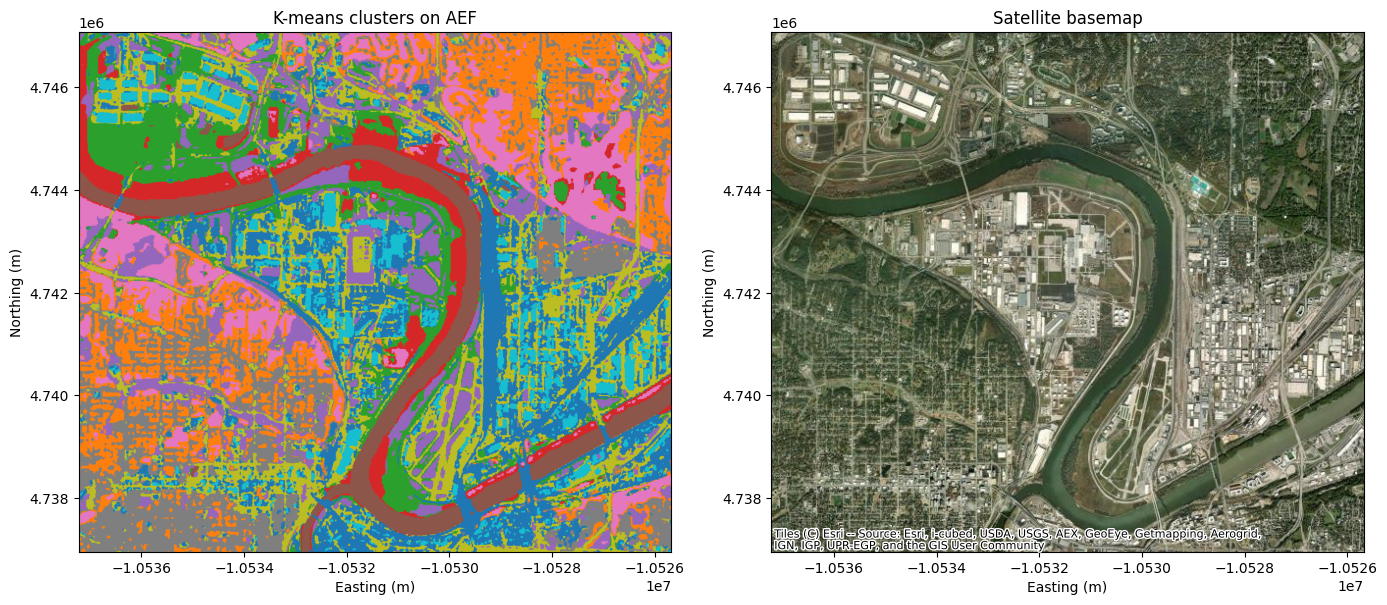

In [4]:
# Create RGB image from cluster indices (qualitative colormap)
cmap = mcolors.ListedColormap(plt.cm.tab10(np.linspace(0, 1, K_VISION)))
cluster_rgba = (cmap(cluster_labels) * 255).astype(np.uint8)
cluster_rgb = cluster_rgba[:, :, :3]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cluster_rgb, extent=extent, origin='upper')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].set_title('K-means clusters on AEF')
axes[1].set_xlim(extent[0], extent[1])
axes[1].set_ylim(extent[2], extent[3])
axes[1].set_aspect('equal')
cx.add_basemap(axes[1], crs=target_crs, source=cx.providers.Esri.WorldImagery)
axes[1].set_title('Satellite basemap')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

## Task 2 — Location query: click on map to get heatmap

Click a point on the map. A heatmap will show similarity (in AEF space) of every pixel to the clicked location.

In [6]:
from ipyleaflet import Map, DrawControl, TileLayer
from ipywidgets import Output, VBox

out_heatmap = Output()

def latlon_to_pixel(lat, lon):
    x, y = transformer.transform(lon, lat)
    col, row = ~geobox.transform * (x, y)
    row, col = int(np.clip(row, 0, H - 1)), int(np.clip(col, 0, W - 1))
    return row * W + col

def on_map_click(**kwargs):
    if kwargs.get('type') != 'click' or 'coordinates' not in kwargs:
        return
    lat, lon = kwargs['coordinates'][0], kwargs['coordinates'][1]  # [lat, lon]
    pid = latlon_to_pixel(lat, lon)
    query_emb = aef_flat[pid:pid+1]
    sim = cosine_similarity(aef_flat, query_emb).ravel()
    heatmap = sim.reshape(H, W)
    with out_heatmap:
        out_heatmap.clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].imshow(heatmap, cmap='magma', extent=extent, origin='upper')
        axes[0].set_title(f'Similarity to clicked point ({lat:.4f}, {lon:.4f})')
        axes[0].set_xlabel('Easting (m)')
        axes[0].set_ylabel('Northing (m)')
        axes[1].set_xlim(extent[0], extent[1])
        axes[1].set_ylim(extent[2], extent[3])
        axes[1].set_aspect('equal')
        cx.add_basemap(axes[1], crs=target_crs, source=cx.providers.Esri.WorldImagery)
        axes[1].set_title('Satellite basemap')
        axes[1].set_xlabel('Easting (m)')
        axes[1].set_ylabel('Northing (m)')
        plt.tight_layout()
        plt.show()

m2 = Map(center=((bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2), zoom=10, scroll_wheel_zoom=True,
      layers=[TileLayer(url='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}')])
m2.on_interaction(on_map_click)
display(VBox([m2, out_heatmap]))

## Task 3 — Text query (OSM tags)

Enter a text query below. We find the most similar OSM tags via CLIP, fetch their geometries in the region, and show heatmaps (average AEF in mask → similarity to each pixel).

In [7]:
OSM_TAGS = [
    "landuse=residential", "landuse=commercial", "landuse=industrial",
    "landuse=farmland", "landuse=forest", "landuse=meadow", "landuse=orchard", "landuse=vineyard",
    "landuse=grass", "landuse=reservoir", "natural=water", "natural=lake", "natural=river", "natural=wood", "natural=forest",
    "natural=wetland", "natural=grassland", "natural=scrub", "highway=residential", "highway=motorway", "highway=trunk", "highway=primary", "highway=secondary",
    "building=yes", "building=house", "waterway=river", "waterway=stream", "waterway=canal",
    "amenity=park", "leisure=park", "leisure=golf_course",
]

def build_overpass_query(bbox, tag_key, tag_value):
    south, west, north, east = bbox[1], bbox[0], bbox[3], bbox[2]
    bbox_str = f"({south},{west},{north},{east})"
    parts = [f"  {t}[\"{tag_key}\"=\"{tag_value}\"]{bbox_str};" for t in ["node", "way", "relation"]]
    return f"""[out:json][timeout:90];\n(\n{"\n".join(parts)}\n);\nout body;\n>;\nout skel qt;\n"""

print(f"OSM_TAGS: {len(OSM_TAGS)} tags defined.")

OSM_TAGS: 31 tags defined.


In [9]:
import requests
import time
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
from rasterio.features import rasterize
from rasterio.transform import from_bounds

from ipywidgets import Text, Button, Output, VBox

text_query = Text(description='Query:', value='road', placeholder='e.g. road, water, forest')
run_btn = Button(description='Run text query')
out_text = Output()

def run_text_query(_):
    with out_text:
        out_text.clear_output(wait=True)
        query = text_query.value.strip() or 'road'
        print(f"Query: '{query}'")
        osm_emb = encode_text(OSM_TAGS)
        q_emb = encode_text([query])
        sims = cosine_similarity(q_emb, osm_emb)[0]
        N_TOP = 5
        top_idx = np.argsort(sims)[::-1][:N_TOP]
        top_osm_tags = [(OSM_TAGS[i], sims[i]) for i in top_idx]
        print("Top OSM tags:", top_osm_tags)

        osm_geometries_overpass = []
        for tag_string, _ in top_osm_tags:
            key, value = tag_string.split('=', 1)
            overpass_ql = build_overpass_query(bbox, key, value)
            try:
                r = requests.post('https://overpass-api.de/api/interpreter', data={'data': overpass_ql}, timeout=90)
                r.raise_for_status()
                data = r.json()
            except Exception as e:
                print(f"Overpass error for {tag_string}: {e}")
                continue
            if 'elements' not in data:
                continue
            features = []
            for el in data['elements']:
                geom = None
                if el['type'] == 'node' and 'lon' in el and 'lat' in el:
                    geom = Point(el['lon'], el['lat'])
                elif el['type'] == 'way' and 'geometry' in el and len(el['geometry']) > 1:
                    coords = [[n['lon'], n['lat']] for n in el['geometry']]
                    geom = Polygon(coords) if coords[0] == coords[-1] and len(coords) > 2 else LineString(coords)
                if geom:
                    features.append({'geometry': geom})
            if features:
                gdf = gpd.GeoDataFrame(features, crs='EPSG:4326')
                osm_geometries_overpass.append({'tag': tag_string, 'gdf': gdf})
            time.sleep(1)

        raster_shape = (H, W)
        geom_transform = from_bounds(extent[0], extent[2], extent[1], extent[3], W, H)
        osm_aef_embeddings = []
        for d in osm_geometries_overpass:
            gdf = d['gdf'].to_crs(target_crs) if d['gdf'].crs != target_crs else d['gdf']
            geoms = [(g, 1) for g in gdf.geometry if g and not g.is_empty and g.is_valid]
            if not geoms:
                continue
            mask = rasterize(geoms, out_shape=raster_shape, transform=geom_transform, fill=0, all_touched=True, dtype=np.uint8)
            flat_mask = mask.flatten()
            masked_aef = aef_flat[flat_mask == 1]
            if len(masked_aef) > 0:
                avg_emb = np.mean(masked_aef, axis=0).reshape(1, -1)
                osm_aef_embeddings.append({'tag': d['tag'], 'embedding': avg_emb})

        if not osm_aef_embeddings:
            print("No OSM geometries with AEF overlap.")
            return

        n_show = 1
        fig, axes = plt.subplots(n_show, 2, figsize=(12, 5 * n_show))
        if n_show == 1:
            axes = axes.reshape(1, -1)
        for i, item in enumerate(osm_aef_embeddings[:n_show]):
            sim = cosine_similarity(aef_flat, item['embedding']).ravel().reshape(H, W)
            axes[i, 0].imshow(sim, cmap='magma', extent=extent, origin='upper')
            axes[i, 0].set_title(f"{item['tag']} — heatmap")
            axes[i, 0].set_xlabel('Easting (m)')
            axes[i, 0].set_ylabel('Northing (m)')
            axes[i, 1].set_xlim(extent[0], extent[1])
            axes[i, 1].set_ylim(extent[2], extent[3])
            axes[i, 1].set_aspect('equal')
            cx.add_basemap(axes[i, 1], crs=target_crs, source=cx.providers.Esri.WorldImagery)
            axes[i, 1].set_title(f"{item['tag']} — satellite")
            axes[i, 1].set_xlabel('Easting (m)')
            axes[i, 1].set_ylabel('Northing (m)')
        plt.suptitle(f"Text query: '{query}'")
        plt.tight_layout()
        plt.show()

run_btn.on_click(run_text_query)
display(VBox([text_query, run_btn, out_text]))

---
# Part 2: Decoding AlphaEarth Embedding (AEF) Dimensions

**Objective:** Map the 64 latent dimensions to human-understandable geospatial concepts using OSM-tagged masks (e.g. 10 tags × 100 masks across US → 1000×64 embeddings).

1. **Supervised Linear Probing** — Logistic Regression per tag; inspect β to see which dimension proxies for which tag.
2. **Cross-Tag Correlation Heatmap** — Centroid per OSM tag; 64×N heatmap (dimensions vs tags).

### Data Preparation: 10 OSM tags × 100 masks across US regions

We use 10 broad OSM tags, query Overpass across US bboxes, and collect ~100 geometries (masks) per tag → 1000 masks. Each mask will get one average AEF embedding (64-d) for dimensionality analysis.

The data preparation takes some time so I have already ran the following cells and have saved prepared data. We will directly load that prepared data in this notebook.

In [10]:
# # Part 2: 10 OSM tags × 100 masks across US → mask_geometries, mask_tags_list (1000 each)
# import requests
# import time
# import numpy as np
# import pandas as pd
# from shapely.geometry import Point, LineString, Polygon, box, box
# from shapely.ops import unary_union
# from collections import defaultdict

# # 10 broad, commonly used OSM tags (key=value) covering major categories
# OSM_TAGS_PART2 = [
#     "building=yes",
#     "highway=primary",
#     "landuse=residential",
#     "landuse=commercial",
#     "landuse=forest",
#     "natural=water",
#     "natural=wood",
#     "landuse=farmland",
#     "leisure=park",
#     "landuse=industrial",
# ]

# # US continental bbox; split into 6 regions to avoid Overpass timeout
# US_W, US_S, US_E, US_N = -125, 24, -66, 50
# STEP_LON, STEP_LAT = (US_E - US_W) / 2, (US_N - US_S) / 2
# US_REGIONS = []
# for i in range(2):
#     for j in range(3):
#         w = US_W + j * STEP_LON
#         e = US_W + (j + 1) * STEP_LON
#         s = US_S + i * STEP_LAT
#         n = US_S + (i + 1) * STEP_LAT
#         US_REGIONS.append((w, s, e, n))

# def build_overpass_query_bbox(bbox, tag_key, tag_value):
#     west, south, east, north = bbox[0], bbox[1], bbox[2], bbox[3]
#     bbox_str = f"({south},{west},{north},{east})"
#     parts = [f'  node["{tag_key}"="{tag_value}"]{bbox_str};', f'  way["{tag_key}"="{tag_value}"]{bbox_str};']
#     return f'[out:json][timeout:90];\n(\n' + '\n'.join(parts) + '\n);\nout body geom;\n>;\nout skel qt;\n'

# def parse_elements_to_geoms(data):
#     geoms = []
#     for el in data.get("elements", []):
#         g = None
#         if el["type"] == "node" and "lon" in el and "lat" in el:
#             g = Point(el["lon"], el["lat"])
#         elif el["type"] == "way" and "geometry" in el and len(el["geometry"]) >= 2:
#             coords = [[n["lon"], n["lat"]] for n in el["geometry"]]
#             g = Polygon(coords) if coords[0] == coords[-1] and len(coords) > 2 else LineString(coords)
#         if g is not None and not g.is_empty and g.is_valid and (not g.is_empty if hasattr(g, 'is_empty') else True):
#             geoms.append(g)
#     return geoms

# mask_geometries = []
# mask_tags_list = []
# MASKS_PER_TAG = 100
# OVERPASS_URL = "https://overpass-api.de/api/interpreter"

# for tag_string in OSM_TAGS_PART2:
#     key, value = tag_string.split("=", 1)
#     collected = []
#     for bbox in US_REGIONS:
#         if len(collected) >= MASKS_PER_TAG:
#             break
#         try:
#             q = build_overpass_query_bbox(bbox, key, value)
#             r = requests.post(OVERPASS_URL, data={"data": q}, timeout=90)
#             r.raise_for_status()
#             data = r.json()
#             geoms = parse_elements_to_geoms(data)
#             for g in geoms:
#                 if len(collected) >= MASKS_PER_TAG:
#                     break
#                 collected.append(g)
#             time.sleep(1.2)
#         except Exception as e:
#             print(f"  Overpass error {tag_string} {bbox}: {e}")
#     n = min(len(collected), MASKS_PER_TAG)
#     for i in range(n):
#         mask_geometries.append(collected[i])
#         mask_tags_list.append(tag_string)
#     print(f"  {tag_string}: {n} masks")

# # Centroids for grid assignment (lon, lat)
# lons_all = np.array([mask_geometries[k].centroid.x for k in range(len(mask_geometries))])
# lats_all = np.array([mask_geometries[k].centroid.y for k in range(len(mask_geometries))])

# GRID_DEG_EXPLORE = 5.0
# RESOLUTION_EXPLORE = 100
# print(f"Total masks: {len(mask_geometries)}. lons_all, lats_all, mask_geometries, mask_tags_list defined.")

In [11]:
# # Save OSM mask data (run once after the data cell above; load later to skip Overpass)
# import pickle

# PART2_MASK_DATA_PATH = "osm_mask_data.pkl"

# with open(PART2_MASK_DATA_PATH, "wb") as f:
#     pickle.dump({
#         "mask_geometries": mask_geometries,
#         "mask_tags_list": mask_tags_list,
#         "lons_all": lons_all,
#         "lats_all": lats_all,
#         "GRID_DEG_EXPLORE": GRID_DEG_EXPLORE,
#         "RESOLUTION_EXPLORE": RESOLUTION_EXPLORE,
#         "OSM_TAGS_PART2": OSM_TAGS_PART2,
#     }, f)
# print(f"Saved to {PART2_MASK_DATA_PATH} ({len(mask_geometries)} masks)")

In [12]:
# """
# Prep Part 2 OSM masks data for aef_interactive_exploration.ipynb: load OSM masks (from Drive or local),
# run grid assignment + Load AEF per cell, then save X_explore, tags_explore, etc. to a pkl.
# Notebook can load that pkl and run Preprocess → Linear probing → Heatmap without re-running AEF.

# Run:  python data_prep.py [--mask-pkl osm_mask_data.pkl] [--out osm_prepped_data.pkl]

# Then in the notebook, use a cell like:
#     import pickle
#     with open("part2_prepped_data.pkl", "rb") as f:
#         d = pickle.load(f)
#     X_explore, tags_explore = d["X_explore"], d["tags_explore"]
#     lons_explore, lats_explore = d["lons_explore"], d["lats_explore"]
#     # then run Preprocess cell
# """
# import argparse
# import gc
# import os
# import pickle
# import asyncio
# import time

# import numpy as np
# try:
#     from tqdm import tqdm
# except ImportError:
#     def tqdm(iterable, **kwargs):
#         return iterable
# from shapely.geometry import box
# from collections import defaultdict
# from rasterio.features import rasterize
# from pyproj import Transformer

# # ---------------------------------------------------------------------------
# # 1) Load OSM mask data (local pkl or download from Drive)
# # ---------------------------------------------------------------------------
# MASK_DATA_PKL = os.environ.get("PART2_MASK_PKL", "osm_mask_data.pkl")
# DRIVE_FILE_ID = "1nCDZXAOmDSJTp6n3QrT_X7Am_h9AZZ0P"
# OUT_PREPPED_PKL = os.environ.get("PART2_PREPPED_PKL", "osm_prepped_data.pkl")


# def load_mask_data(mask_path=None, from_drive_if_missing=True):
#     mask_path = mask_path or MASK_DATA_PKL
#     if os.path.exists(mask_path):
#         with open(mask_path, "rb") as f:
#             d = pickle.load(f)
#         print(f"Loaded mask data from {mask_path}: {len(d['mask_geometries'])} masks.")
#         return d
#     if from_drive_if_missing:
#         try:
#             import gdown
#             url = f"https://drive.google.com/uc?export=download&id={DRIVE_FILE_ID}"
#             gdown.download(url, mask_path, quiet=False, fuzzy=True)
#             with open(mask_path, "rb") as f:
#                 d = pickle.load(f)
#             print(f"Downloaded and loaded from Drive → {mask_path}: {len(d['mask_geometries'])} masks.")
#             return d
#         except Exception as e:
#             print(f"Download failed: {e}. Place {MASK_DATA_PKL} locally or set PART2_MASK_PKL.")
#             raise
#     raise FileNotFoundError(f"Mask data not found: {mask_path}")


# # ---------------------------------------------------------------------------
# # 2) Grid assignment
# # ---------------------------------------------------------------------------
# def build_grid_assignment(mask_geometries, grid_deg):
#     def cell_to_bbox(i, j, gdeg):
#         w = i * gdeg - 180
#         s = j * gdeg - 90
#         return (w, s, (i + 1) * gdeg - 180, (j + 1) * gdeg - 90)

#     def cell_polygon(i, j, gdeg):
#         w, s, e, n = cell_to_bbox(i, j, gdeg)
#         return box(w, s, e, n)

#     cell_to_indices = defaultdict(list)
#     for k, geom in enumerate(mask_geometries):
#         if geom.is_empty or not geom.is_valid:
#             continue
#         env = geom.bounds
#         i_min = int((env[0] + 180) // grid_deg)
#         i_max = int((env[2] + 180) // grid_deg)
#         j_min = int((env[1] + 90) // grid_deg)
#         j_max = int((env[3] + 90) // grid_deg)
#         for i in range(i_min, i_max + 1):
#             for j in range(j_min, j_max + 1):
#                 if geom.intersects(cell_polygon(i, j, grid_deg)):
#                     cell_to_indices[(i, j)].append(k)
#     cells_explore = list(cell_to_indices.keys())
#     return cell_to_bbox, cell_polygon, cell_to_indices, cells_explore


# # ---------------------------------------------------------------------------
# # 3) Load AEF per mask (one small query per mask) → X_explore, tags_explore, ...
# # ---------------------------------------------------------------------------
# def run_aef_loading(
#     mask_geometries,
#     mask_tags_list,
#     lons_all,
#     lats_all,
#     resolution=500,
#     target_crs="EPSG:3857",
#     year=2024,
#     max_concurrent=3,
# ):
#     import nest_asyncio
#     nest_asyncio.apply()
#     from odc.geo.geobox import GeoBox
#     from aef_loader import AEFIndex, VirtualTiffReader, DataSource
#     from aef_loader.utils import dequantize_aef, reproject_datatree

#     transformer_explore = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
#     N_MASKS = len(mask_geometries)
#     mask_emb_sum = np.zeros((N_MASKS, 64))
#     mask_count = np.zeros(N_MASKS)

#     async def load_aef_bbox(index, bbox_4326):
#         """Load AEF for one small bbox (one mask's extent). Returns (grid HxWx64, geobox)."""
#         x_min, y_min = transformer_explore.transform(bbox_4326[0], bbox_4326[1])
#         x_max, y_max = transformer_explore.transform(bbox_4326[2], bbox_4326[3])
#         geobox = GeoBox.from_bbox(
#             bbox=(x_min, y_min, x_max, y_max), crs=target_crs, resolution=resolution
#         )
#         tiles = await index.query(bbox=bbox_4326, years=(year, year))
#         async with VirtualTiffReader() as reader:
#             tree = await reader.open_tiles_by_zone(tiles)
#         combined = reproject_datatree(tree, target_geobox=geobox)
#         emb = combined.embeddings.isel(time=0)
#         if hasattr(emb, "data") and hasattr(emb.data, "compute"):
#             emb = emb.compute()
#         raw = dequantize_aef(emb).values
#         out = np.moveaxis(raw, 0, -1).copy()
#         return out, geobox

#     async def run_all_masks():
#         index = AEFIndex(source=DataSource.SOURCE_COOP)
#         await index.download()
#         sem = asyncio.Semaphore(max_concurrent)

#         async def load_for_mask(k):
#             geom = mask_geometries[k]
#             if geom.is_empty or not geom.is_valid:
#                 return k, None
#             bbox = geom.bounds
#             async with sem:
#                 try:
#                     grid, geobox = await load_aef_bbox(index, bbox)
#                     return k, (grid, geobox, bbox)
#                 except Exception as e:
#                     return k, (e,)

#         tasks = [load_for_mask(k) for k in range(N_MASKS)]
#         try:
#             from tqdm.asyncio import tqdm as atqdm
#             return await atqdm.gather(*tasks, desc="Load AEF/mask")
#         except ImportError:
#             return await asyncio.gather(*tasks)

#     print("  Index download + loading AEF per mask (small bbox each)...")
#     t0 = time.perf_counter()
#     results = asyncio.run(run_all_masks())
#     print(f"  All loads done: {time.perf_counter() - t0:.1f}s")

#     from shapely.ops import transform as sh_transform
#     proj = lambda x, y: transformer_explore.transform(x, y)
#     t_agg = time.perf_counter()
#     for k, (_, payload) in tqdm(enumerate(results), total=N_MASKS, desc="Aggregate masks"):
#         if payload is None or (isinstance(payload, tuple) and len(payload) == 1):
#             continue
#         grid, geobox, bbox_4326 = payload
#         H, W = grid.shape[0], grid.shape[1]
#         transform = geobox.transform
#         geom = mask_geometries[k]
#         cell_poly = box(bbox_4326[0], bbox_4326[1], bbox_4326[2], bbox_4326[3])
#         try:
#             inter = geom.intersection(cell_poly)
#         except Exception:
#             continue
#         if inter.is_empty:
#             continue
#         geoms_attr = getattr(inter, "geoms", None)
#         geoms_to_raster = (
#             [g for g in geoms_attr if not g.is_empty]
#             if geoms_attr is not None
#             else ([inter] if not inter.is_empty else [])
#         )
#         if not geoms_to_raster:
#             continue
#         geoms_3857 = [sh_transform(proj, g) for g in geoms_to_raster]
#         shapes = [(g, 1) for g in geoms_3857 if g and not g.is_empty]
#         if not shapes:
#             continue
#         mask_raster = rasterize(
#             shapes, out_shape=(H, W), transform=transform,
#             fill=0, all_touched=True, dtype=np.uint8
#         )
#         flat = mask_raster.flatten()
#         n_pix = flat.sum()
#         if n_pix == 0:
#             continue
#         aef_flat = grid.reshape(-1, 64)
#         mean_emb = aef_flat[flat == 1].sum(axis=0) / n_pix
#         mask_emb_sum[k] += mean_emb * n_pix
#         mask_count[k] += n_pix
#         del grid
#     gc.collect()
#     print(f"  Aggregate: {time.perf_counter() - t_agg:.1f}s")

#     valid = mask_count > 0
#     X_explore = np.zeros((N_MASKS, 64))
#     X_explore[valid] = mask_emb_sum[valid] / mask_count[valid, None]
#     tags_explore = np.array(mask_tags_list, dtype=object)
#     lons_explore = lons_all.copy()
#     lats_explore = lats_all.copy()
#     X_explore = X_explore[valid]
#     tags_explore = tags_explore[valid]
#     lons_explore = lons_explore[valid]
#     lats_explore = lats_explore[valid]
#     return X_explore, tags_explore, lons_explore, lats_explore


# # ---------------------------------------------------------------------------
# # Main: load masks → grid → AEF → save prepped pkl
# # ---------------------------------------------------------------------------
# def main():
#     p = argparse.ArgumentParser(description="Prep Part 2 data and save for notebook.")
#     p.add_argument("--mask-pkl", default=MASK_DATA_PKL, help="Input mask data pkl (or download from Drive if missing)")
#     p.add_argument("--out", default=OUT_PREPPED_PKL, help="Output prepped data pkl for notebook")
#     p.add_argument("--no-drive", action="store_true", help="Do not download from Drive if mask pkl missing")
#     p.add_argument("--resolution", type=int, default=10, help="AEF pixel size in meters; larger = coarser = faster (e.g. 100 or 200)")
#     p.add_argument("--max-concurrent", type=int, default=3, help="Max concurrent AEF loads per mask (default 3)")
#     args = p.parse_args()

#     d = load_mask_data(mask_path=args.mask_pkl, from_drive_if_missing=not args.no_drive)
#     mask_geometries = d["mask_geometries"]
#     mask_tags_list = d["mask_tags_list"]
#     lons_all = d["lons_all"]
#     lats_all = d["lats_all"]
#     RESOLUTION_EXPLORE = d.get("RESOLUTION_EXPLORE", args.resolution)

#     print("Loading AEF per mask (one small query per mask)...")
#     X_explore, tags_explore, lons_explore, lats_explore = run_aef_loading(
#         mask_geometries,
#         mask_tags_list,
#         lons_all,
#         lats_all,
#         resolution=RESOLUTION_EXPLORE,
#         max_concurrent=args.max_concurrent,
#     )
#     print(f"  X_explore shape: {X_explore.shape}")

#     out_data = {
#         "X_explore": X_explore,
#         "tags_explore": tags_explore,
#         "lons_explore": lons_explore,
#         "lats_explore": lats_explore,
#     }
#     with open(args.out, "wb") as f:
#         pickle.dump(out_data, f)
#     print(f"Saved to {args.out}. In the notebook, load this and set X_explore, tags_explore, lons_explore, lats_explore then run Preprocess.")


# if __name__ == "__main__":
#     main()


### load prepared data

In [5]:
import os
import pickle
from pathlib import Path

# Data from shared Drive folder (no auth): this notebook needs only osm_prepped_data.pkl
DRIVE_FOLDER_ID = "1lbL3juj2hkUhBTDJL78wvlb5F6SIDtAe"
PREPPED_FILE_ID = "1TmoL5rkvvkfioo0IvGeeqZYG7nfSD0hA"
try:
    CACHE_DIR = Path("/content/drive_data") if IN_COLAB else Path("drive_data")
except NameError:
    CACHE_DIR = Path("drive_data")
PREPPED_PKL_PATH = CACHE_DIR / "osm_prepped_data.pkl"

if not PREPPED_PKL_PATH.exists():
    try:
        import gdown
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=False)
        import gdown
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    gdown.download(
        f"https://drive.google.com/uc?export=download&id={PREPPED_FILE_ID}",
        str(PREPPED_PKL_PATH), quiet=False, fuzzy=True
    )

with open(PREPPED_PKL_PATH, "rb") as f:
    d = pickle.load(f)
X_explore, tags_explore = d["X_explore"], d["tags_explore"]
lons_explore, lats_explore = d["lons_explore"], d["lats_explore"]
print(f"Loaded Part 2 prepped data from {PREPPED_PKL_PATH}: X_explore {X_explore.shape}, {len(tags_explore)} masks")

Downloading...
From: https://drive.google.com/uc?id=1TmoL5rkvvkfioo0IvGeeqZYG7nfSD0hA
To: /content/drive_data/osm_prepped_data.pkl
100%|██████████| 523k/523k [00:00<00:00, 92.3MB/s]

Loaded Part 2 prepped data from /content/drive_data/osm_prepped_data.pkl: X_explore (986, 64), 986 masks


### Preprocess: normalize embeddings, binary-encode tags

In [6]:
from sklearn.preprocessing import StandardScaler

X_tag = X_explore
tags_tag = tags_explore
keep_tags = set(tags_tag)
tag_set = sorted(keep_tags)
tag_to_col = {t: i for i, t in enumerate(tag_set)}
Y_binary = np.zeros((len(tags_tag), len(tag_set)))
for i, t in enumerate(tags_tag):
    if t in tag_to_col:
        Y_binary[i, tag_to_col[t]] = 1

X_norm = StandardScaler().fit_transform(X_tag)
print(f"X_norm: {X_norm.shape}, Y_binary: {Y_binary.shape}, tags: {len(tag_set)}")

X_norm: (986, 64), Y_binary: (986, 10), tags: 10


### Supervised linear probing

Train one Logistic Regression per tag (one-vs-rest). Coefficients β show which dimension best predicts each tag; assign each dimension to its top tag.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

coefs = np.zeros((64, len(tag_set)))
trained_lr_models = [] # Store trained models

for j, tag in enumerate(tag_set):
    y = Y_binary[:, j]
    if y.sum() < 10:
        # Not enough samples for this tag, skip training
        trained_lr_models.append(None) # Add None for consistency
        continue
    X_tr, X_te, y_tr, y_te = train_test_split(X_norm, y, test_size=0.2, random_state=42, stratify=y)
    clf = LogisticRegression(max_iter=500, C=0.1, random_state=42)
    clf.fit(X_tr, y_tr)
    coefs[:, j] = clf.coef_[0]
    trained_lr_models.append(clf) # Store the trained classifier

# Tag → top proxy dimension
dim_proxy = np.argmax(np.abs(coefs), axis=0)
print("Tag → top proxy dimension:")
for j, tag in enumerate(tag_set):
    d = dim_proxy[j]
    # Check if a model was trained for this tag before printing coef
    if trained_lr_models[j] is not None:
        print(f"  {tag}: dim {d} (coef={coefs[d, j]:.4f})")
    else:
        print(f"  {tag}: (not enough samples to train)")

# Dimension → assigned OSM tag (top coefficient)
N_TOP_TAGS_PER_DIM = 3
dim_to_tags = []
for d in range(64):
    order = np.argsort(np.abs(coefs[d, :]))[::-1]
    top_tags = [tag_set[j] for j in order[:N_TOP_TAGS_PER_DIM] if trained_lr_models[j] is not None] # Filter out skipped tags
    assigned = top_tags[0] if len(top_tags) else ""
    dim_to_tags.append({"dim": d, "assigned_tag": assigned, "top_tags": top_tags})
dim_tags_df = pd.DataFrame(dim_to_tags)
display(dim_tags_df[["dim", "assigned_tag", "top_tags"]])
dim_tags_df.to_csv("aef_64d_dim_to_osm_tags.csv", index=False)

Tag → top proxy dimension:
  building=yes: dim 61 (coef=-0.4038)
  highway=primary: dim 25 (coef=-0.4857)
  landuse=commercial: dim 16 (coef=0.4913)
  landuse=farmland: dim 29 (coef=-0.5076)
  landuse=forest: dim 62 (coef=-0.4380)
  landuse=industrial: dim 8 (coef=-0.4952)
  landuse=residential: dim 24 (coef=0.5704)
  leisure=park: dim 25 (coef=0.4486)
  natural=water: dim 25 (coef=-0.5561)
  natural=wood: dim 31 (coef=-0.7153)


,dim,assigned_tag,top_tags
0,0,landuse=industrial,"[landuse=industrial, landuse=forest, highway=p..."
1,1,landuse=farmland,"[landuse=farmland, landuse=commercial, landuse..."
2,2,landuse=industrial,"[landuse=industrial, natural=wood, landuse=res..."
3,3,leisure=park,"[leisure=park, natural=water, building=yes]"
4,4,landuse=commercial,"[landuse=commercial, natural=wood, landuse=for..."
...,...,...,...
59,59,landuse=industrial,"[landuse=industrial, building=yes, landuse=far..."
60,60,natural=water,"[natural=water, leisure=park, highway=primary]"
61,61,building=yes,"[building=yes, highway=primary, landuse=commer..."
62,62,landuse=commercial,"[landuse=commercial, landuse=forest, natural=w..."


### Cross-tag correlation heatmap

Centroid = mean AEF embedding per tag. Heatmap: 64 dimensions × N tags (centroid values and/or correlation of each dimension with each binary tag).

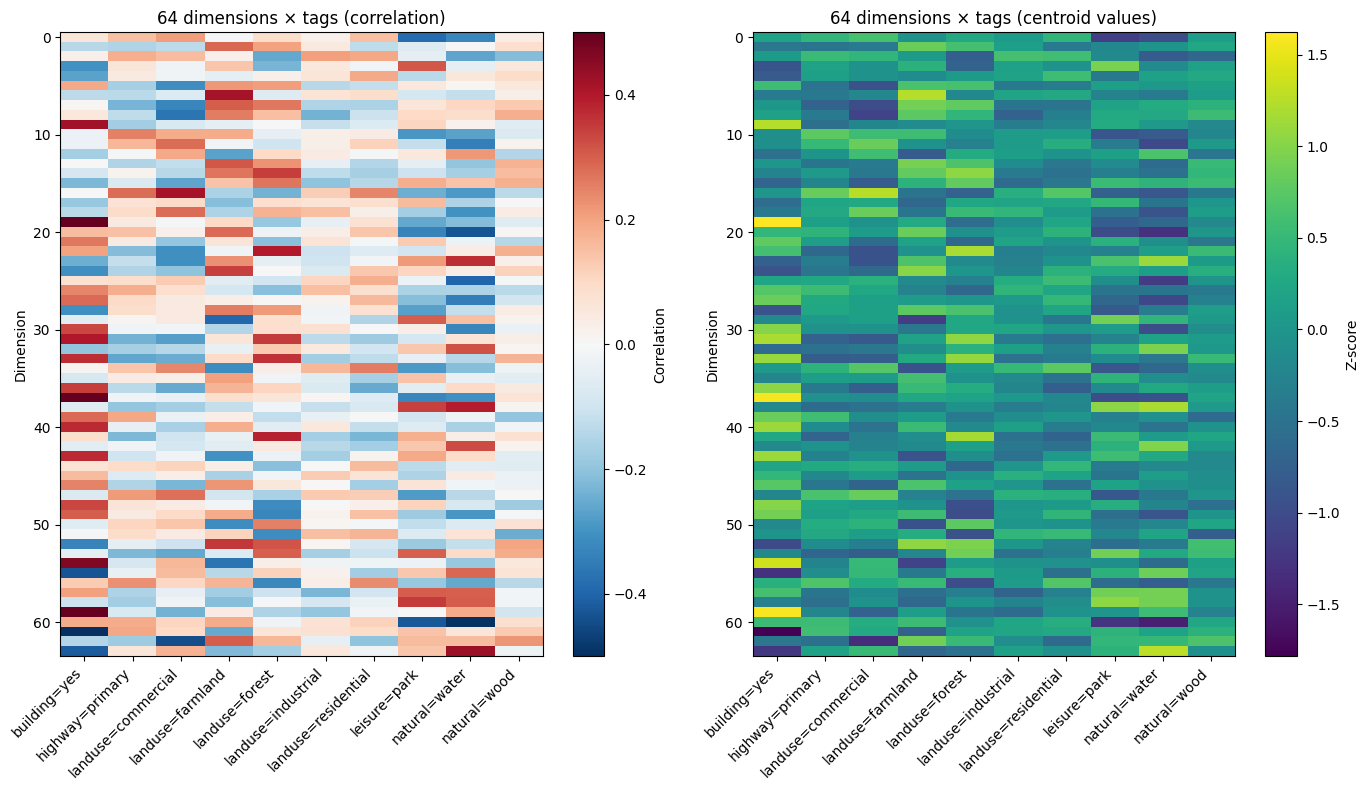

In [8]:
# Centroid per tag (mean AEF)
centroids = np.zeros((64, len(tag_set)))
for j in range(len(tag_set)):
    mask = Y_binary[:, j] == 1
    if mask.sum() > 0:
        centroids[:, j] = X_norm[mask].mean(axis=0)

# Correlation of each dimension with each binary tag
corr_dim_tag = np.zeros((64, len(tag_set)))
for d in range(64):
    for j in range(len(tag_set)):
        r = np.corrcoef(X_norm[:, d], Y_binary[:, j])[0, 1]
        corr_dim_tag[d, j] = r if not np.isnan(r) else 0

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
im0 = axes[0].imshow(corr_dim_tag, aspect="auto", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[0].set_xticks(range(len(tag_set)))
axes[0].set_xticklabels(tag_set, rotation=45, ha="right")
axes[0].set_ylabel("Dimension")
axes[0].set_title("64 dimensions × tags (correlation)")
plt.colorbar(im0, ax=axes[0], label="Correlation")

im1 = axes[1].imshow(centroids, aspect="auto", cmap="viridis")
axes[1].set_xticks(range(len(tag_set)))
axes[1].set_xticklabels(tag_set, rotation=45, ha="right")
axes[1].set_ylabel("Dimension")
axes[1].set_title("64 dimensions × tags (centroid values)")
plt.colorbar(im1, ax=axes[1], label="Z-score")
plt.tight_layout()
plt.show()

### PCA and t-SNE visualization

Project the 64-d AEF embeddings to 2D with PCA and t-SNE; color points by OSM tag to see whether tags form clusters.

/tmp/ipykernel_1706/340426690.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(n_tags, 10))
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


PCA: explained variance ratio [0.16412662 0.11979347] (total: 0.284)


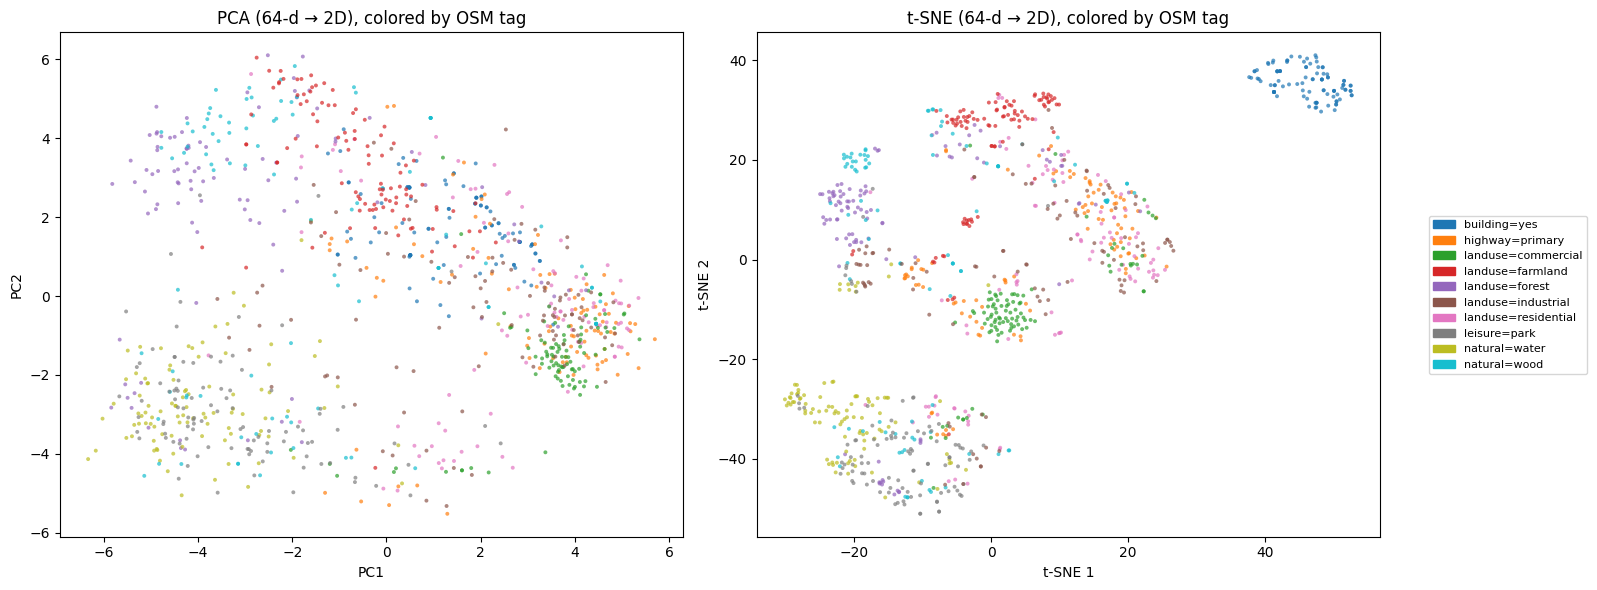

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Color each sample by its OSM tag (use tag_set order for consistent colors)
n_tags = len(tag_set)
cmap = plt.cm.get_cmap("tab10", max(n_tags, 10))
colors = [cmap(j % 10) for j in range(n_tags)]  # one color per tag for legend
tag_colors = [colors[tag_to_col[t]] for t in tags_tag]

# --- PCA: 2 components on normalized embeddings ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_norm)
print(f"PCA: explained variance ratio {pca.explained_variance_ratio_} (total: {pca.explained_variance_ratio_.sum():.3f})")

# --- t-SNE: 2D (can be slow for 1000 points; use perplexity 30–50) ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_norm)

# --- Plot both: scatter colored by OSM tag ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=tag_colors, s=8, alpha=0.7, edgecolors="none")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA (64-d → 2D), colored by OSM tag")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=tag_colors, s=8, alpha=0.7, edgecolors="none")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].set_title("t-SNE (64-d → 2D), colored by OSM tag")

# Legend: one patch per tag
handles = [plt.matplotlib.patches.Patch(color=colors[j], label=tag_set[j]) for j in range(n_tags)]
fig.legend(handles=handles, bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)
plt.tight_layout()
plt.show()

### Pixel-wise Classification using Logistic Regression Models

This section applies the previously trained Logistic Regression models (from Part 2, which map AEF dimensions to OSM tags) to the AEF embeddings of your selected region of interest. Each pixel in the region will be classified as the OSM tag for which the corresponding model predicts the highest probability. The results are displayed as a color-coded map alongside a satellite basemap.

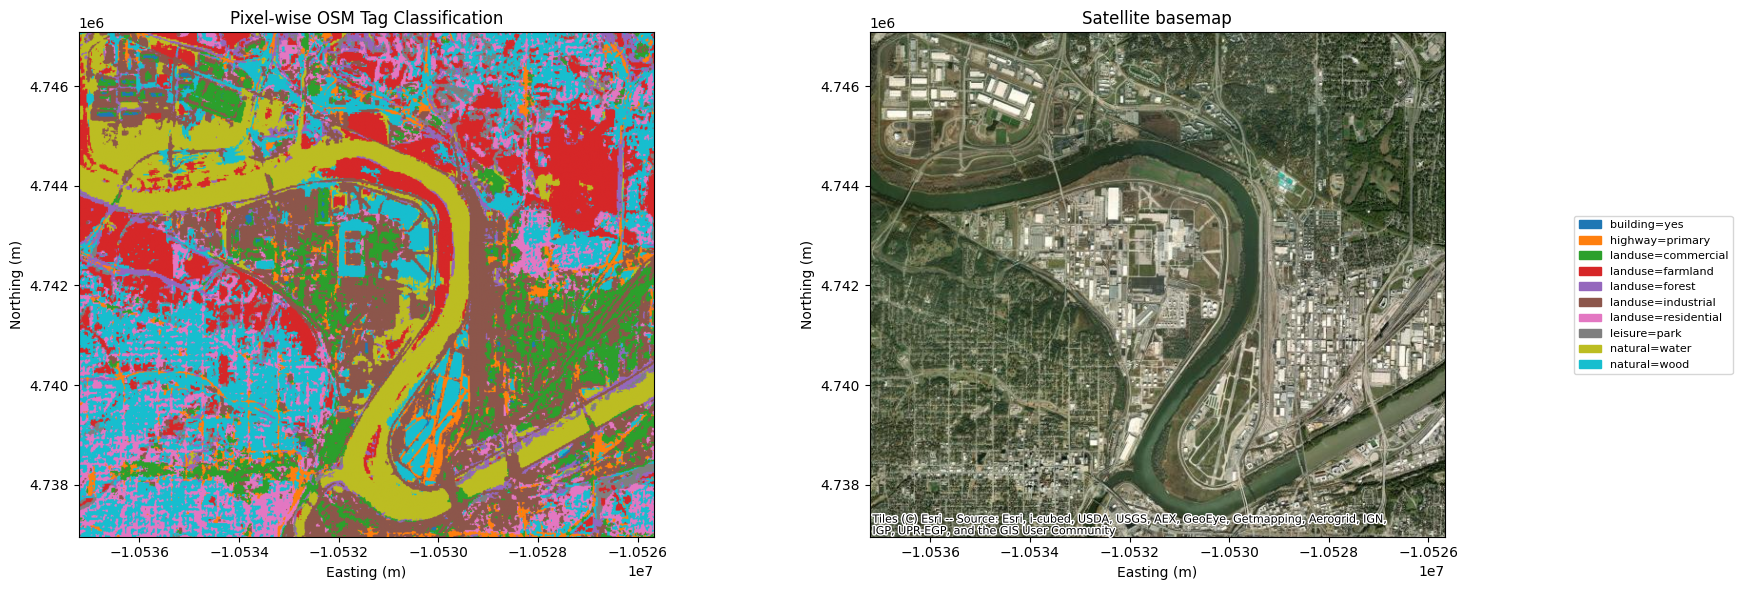

In [10]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Ensure `aef_flat` is normalized using the same scaler or a new one fit to current data
# For consistent application of LR models, it's best to normalize aef_flat in the same way X_explore was.
# X_norm was created using StandardScaler().fit_transform(X_tag).
# Here, we'll fit a new scaler to aef_flat for the ROI, assuming it's representative.
# If you want to use the *exact* same scaling as Part 2 data, you'd need to save/load that scaler.

scaler_roi = StandardScaler()
aef_flat_norm_roi = scaler_roi.fit_transform(aef_flat)

# Initialize an array to store predicted probabilities for each class for each pixel
# The number of classes is len(tag_set)
all_pixel_probs = np.zeros((aef_flat_norm_roi.shape[0], len(tag_set)))

# Iterate through each trained model and predict probabilities
# Filter out models that were not trained (e.g., due to insufficient samples)
for j, tag in enumerate(tag_set):
    clf = trained_lr_models[j]
    if clf is not None: # Only use successfully trained models
        # Get probabilities for the positive class (class 1)
        # Some classifiers might only have 1 class if y only had one unique value
        if len(clf.classes_) > 1:
            all_pixel_probs[:, j] = clf.predict_proba(aef_flat_norm_roi)[:, 1]
        elif clf.classes_[0] == 1: # If only class 1 was present, all predictions might be 1
             all_pixel_probs[:, j] = clf.predict(aef_flat_norm_roi)

# Determine the most probable class for each pixel
# If no model was trained for a tag, its probability will be 0, so argmax will pick another one.
predicted_labels_flat = np.argmax(all_pixel_probs, axis=1)
predicted_labels_grid = predicted_labels_flat.reshape(H, W)

# Create a colormap for the OSM tags
# Using the same tab10 colormap as for K-means clusters for consistency or create a new one
n_tags_for_plot = len(tag_set)
osm_cmap = mcolors.ListedColormap(plt.cm.tab10(np.linspace(0, 1, n_tags_for_plot)))

# Map predicted labels to colors
prediction_rgba = (osm_cmap(predicted_labels_grid / (n_tags_for_plot - 1)) * 255).astype(np.uint8)
prediction_rgb = prediction_rgba[:, :, :3]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Classified Map
axes[0].imshow(predicted_labels_grid, cmap=osm_cmap, extent=extent, origin='upper',
               vmin=0, vmax=n_tags_for_plot-1)
axes[0].set_title('Pixel-wise OSM Tag Classification')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

# Plot 2: Satellite basemap
axes[1].set_xlim(extent[0], extent[1])
axes[1].set_ylim(extent[2], extent[3])
axes[1].set_aspect('equal')
cx.add_basemap(axes[1], crs=target_crs, source=cx.providers.Esri.WorldImagery)
axes[1].set_title('Satellite basemap')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

# Create a custom legend for the classified map
handles = [mpatches.Patch(color=osm_cmap(j / (n_tags_for_plot - 1)), label=tag_set[j])
           for j in range(n_tags_for_plot)]
fig.legend(handles=handles, bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)

plt.tight_layout()
plt.show()